# Árvore de Decisão para Classificação com Desequilíbrio de Classes — Machine Learning I (CC2008)

**Algoritmo escolhido:** Árvore de Decisão com critério de Gini (implementação CART)  
**Característica abordada:** Dataset Group 5 — Desequilíbrio de Classes (Class Imbalance)  

A Árvore de Decisão é implementada de raiz com base na estrutura CART (Classification and Regression Trees). Neste notebook, a estratégia de melhoria é o **Reduced Error Pruning (REP)** — uma técnica de poda pós-crescimento que remove sub-árvores cujo contributo não é validado empiricamente num conjunto de validação independente.

## Setup Inicial

Importação das dependências. Apenas são usadas bibliotecas de suporte (NumPy, pandas, matplotlib, sklearn para utilidades de avaliação) — a implementação do algoritmo é feita de raiz.

In [1]:
import numpy as np
import pandas as pd
import random
import warnings
from functools import partial
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# ── Configuração global ───────────────────────────────────────────────────────
RANDOM_STATE = 42
N_FOLDS      = 5
MAX_DEPTH    = 5
MIN_SAMPLES  = 5
MAX_SAMPLES  = 500   
DATA_DIR     = Path('data/class_imbalance/class_imbalance')

## Critério de Impureza de Gini

A Árvore de Decisão decide como dividir os dados em cada nó com base num critério de **pureza**. O critério standard para classificação é o **índice de Gini**:

$$\text{Gini}(S) = 1 - \sum_{c=1}^{k} p_c^2$$

onde $p_c$ é a proporção da classe $c$ no conjunto $S$, e $k$ é o número de classes. Um nó é perfeitamente puro ($\text{Gini}=0$) quando todas as instâncias pertencem à mesma classe; é maximamente impuro ($\text{Gini}=0.5$ para $k=2$) quando as classes estão em proporções iguais.

O **ganho de Gini** para uma divisão $S \to S_L \cup S_R$ é:

$$\Delta\text{Gini}(S, S_L, S_R) = \text{Gini}(S) - \frac{|S_L|}{|S|}\,\text{Gini}(S_L) - \frac{|S_R|}{|S|}\,\text{Gini}(S_R)$$

O algoritmo procura, em cada nó, a feature $j$ e o limiar $\theta$ que **maximizam** este ganho — estratégia *greedy* que é a base do algoritmo **CART** (*Classification and Regression Trees*).

As funções auxiliares de divisão dos dados são apresentadas abaixo.

In [2]:
def split(X_col, y, value):
    """Separa os rótulos y pelo limiar value aplicado à coluna X_col."""
    y = np.asarray(y).ravel()
    left_mask = X_col < value
    return y[left_mask], y[~left_mask]


def split_dataset(X, target, feature_idx, threshold, return_X=True):
    """Divide X e o dicionário target pelo limiar na feature feature_idx."""
    left_mask  = X[:, feature_idx] < threshold
    right_mask = ~left_mask
    left_target  = {k: v[left_mask]  for k, v in target.items()}
    right_target = {k: v[right_mask] for k, v in target.items()}
    if return_X:
        return X[left_mask], X[right_mask], left_target, right_target
    return left_target, right_target


print("Funções auxiliares de divisão definidas.")

Funções auxiliares de divisão definidas.


## Implementação da Árvore de Decisão (de raiz)

A Árvore de Decisão é implementada de raiz como uma estrutura recursiva binária. Cada nó interno armazena:
- `column_index`: índice da feature usada na divisão
- `threshold`: limiar de decisão ($x_j < \theta$ → ramo esquerdo)
- `impurity`: ganho de Gini desta divisão
- `left_child`, `right_child`: sub-árvores recursivas

Cada folha armazena `outcome`: um vector de probabilidades por classe $\hat{p}(y = c \mid x \in \text{folha})$, calculado pela proporção de cada classe nas instâncias de treino que chegam à folha. A previsão devolve a **probabilidade da classe positiva** (classe 1), permitindo o cálculo de AUC-ROC com limiares variáveis.

O treino segue o algoritmo CART:
1. Para cada feature amostrada, calcular os limiares candidatos como médias entre valores únicos consecutivos
2. Escolher a divisão com maior ganho de Gini
3. Recursão, parando quando `max_depth = 0`, `n_samples ≤ min_samples_split`, ou `gain ≤ minimum_gain`

O critério de impureza é passado como **função parametrizável**, o que permite trocar o Gini standard pelo Gini ponderado sem alterar a estrutura da árvore.

In [3]:
class Tree(object):
    """Implementação recursiva de uma árvore de decisão binária."""

    def __init__(self, regression=False, criterion=None, n_classes=None):
        self.regression    = regression
        self.criterion     = criterion
        self.n_classes     = n_classes
        self.impurity      = None
        self.threshold     = None
        self.column_index  = None
        self.outcome       = None
        self.loss          = None
        self.left_child    = None
        self.right_child   = None

    @property
    def is_terminal(self):
        return not bool(self.left_child and self.right_child)

    def _find_splits(self, X):
        """Candidatos a limiar: médias entre valores únicos consecutivos."""
        x_unique = np.unique(X)
        return [(x_unique[i - 1] + x_unique[i]) / 2.0 for i in range(1, len(x_unique))]

    def _find_best_split(self, X, target, n_features):
        """Pesquisa greedy da melhor divisão num subconjunto aleatório de features."""
        subset = random.sample(range(X.shape[1]), n_features)
        max_gain, max_col, max_val = None, None, None

        for column in subset:
            for value in self._find_splits(X[:, column]):
                splits = split(X[:, column], target["y"], value)
                gain   = self.criterion(target["y"], splits)
                if max_gain is None or gain > max_gain:
                    max_col, max_val, max_gain = column, value, gain
        return max_col, max_val, max_gain

    def _train(self, X, target, max_features=None, min_samples_split=10,
               max_depth=None, minimum_gain=0.0):
        try:
            assert X.shape[0] > min_samples_split
            assert max_depth > 0
            if max_features is None:
                max_features = X.shape[1]

            column, value, gain = self._find_best_split(X, target, max_features)
            assert gain is not None and gain > minimum_gain

            self.column_index = column
            self.threshold    = value
            self.impurity     = gain

            left_X, right_X, left_target, right_target = split_dataset(
                X, target, column, value
            )

            self.left_child = Tree(self.regression, self.criterion, self.n_classes)
            self.left_child._train(left_X, left_target, max_features,
                                   min_samples_split, max_depth - 1, minimum_gain)

            self.right_child = Tree(self.regression, self.criterion, self.n_classes)
            self.right_child._train(right_X, right_target, max_features,
                                    min_samples_split, max_depth - 1, minimum_gain)
        except AssertionError:
            self._calculate_leaf_value(target)

    def train(self, X, target, max_features=None, min_samples_split=10,
              max_depth=None, minimum_gain=0.0):
        """Treina a árvore a partir de X (features) e target (rótulos)."""
        if not isinstance(target, dict):
            target = {"y": np.asarray(target, dtype=int)}
        if not self.regression:
            self.n_classes = len(np.unique(target["y"]))
        self._train(X, target, max_features=max_features,
                    min_samples_split=min_samples_split,
                    max_depth=max_depth, minimum_gain=minimum_gain)

    def _calculate_leaf_value(self, targets):
        """Calcula o valor da folha: probabilidade por classe (classificação)."""
        y = targets["y"].astype(int)
        if self.n_classes is None:
            self.n_classes = int(y.max()) + 1
        self.outcome = np.bincount(y, minlength=self.n_classes) / len(y)

    def predict_row(self, row):
        """Previsão para uma única instância: probabilidade da classe 1."""
        if not self.is_terminal:
            child = self.left_child if row[self.column_index] < self.threshold \
                    else self.right_child
            return child.predict_row(row)
        if isinstance(self.outcome, np.ndarray):
            return self.outcome[1]   # P(y=1)
        return float(self.outcome)

    def predict(self, X):
        """Devolve P(y=1) para cada linha de X."""
        return np.array([self.predict_row(X[i]) for i in range(X.shape[0])])


print("Classe Tree definida (CART, critério parametrizável).")

Classe Tree definida (CART, critério parametrizável).


## Árvore de Decisão e Desequilíbrio de Classes — Análise Teórica

### O Problema do Desequilíbrio de Classes

Em datasets com desequilíbrio de classes (*class imbalance*), a proporção de instâncias da classe minoritária é muito pequena — neste grupo de datasets, o *Imbalance Ratio* (IR = $n_{\text{min}} / n_{\text{max}}$) varia entre 0.007 e 0.24. Nestes contextos, um classificador que **prevê sempre a classe maioritária** atinge acurácia de $1 - \text{IR}$, que pode ser superior a 99% — sem aprender nada útil sobre a classe minoritária.

### Por que o Gini Standard é Problemático?

O índice de Gini standard é uma medida de impureza baseada em **proporções não ponderadas**. Em dados muito desbalanceados, isto gera três problemas:

**1. Divisões que ignoram a classe minoritária são recompensadas.**  
Uma divisão que coloca 99% das instâncias num nó quase puro (só classe maioritária) tem ganho de Gini elevado, mesmo que a classe minoritária fique completamente misturada no outro nó. O algoritmo "aprende" a ignorar a classe minoritária porque isso maximiza o Gini.

**2. Folhas maioritárias dominam a predição.**  
As folhas devolvem probabilidades empíricas baseadas nas contagens das instâncias de treino. Nós com muitas instâncias da classe maioritária produzem folhas com $\hat{p}(y=1)$ muito baixo, enviesando o modelo.

**3. O limiar de decisão standard de 0.5 é inapropriado.**  
Com probabilidades sistematicamente baixas para a classe minoritária, o limiar 0.5 faz com que o modelo raramente preveja essa classe, resultando em F1 e G-mean próximos de zero apesar de uma acurácia elevada.

### Hipótese

> O desequilíbrio de classes afecta negativamente e de forma mensurável o desempenho da Árvore de Decisão com Gini standard, especialmente nas métricas F1 e G-mean da classe minoritária. A degradação deverá ser proporcional à severidade do desequilíbrio (IR baixo). Esta hipótese será avaliada empiricamente na Fase 1.

In [4]:
def gini_impurity(y, splits):
    """Ganho de Gini standard (não ponderado)."""
    y_left, y_right = splits
    if len(y_left) == 0 or len(y_right) == 0:
        return 0

    def _gini(labels):
        if len(labels) == 0:
            return 0
        probs = np.bincount(labels) / len(labels)
        return 1 - np.sum(probs ** 2)

    n = len(y_left) + len(y_right)
    parent = _gini(np.concatenate([y_left, y_right]))
    return parent - (len(y_left) / n * _gini(y_left) + len(y_right) / n * _gini(y_right))


print("Critério de Gini standard definido.")

Critério de Gini standard definido.


In [5]:
def gini_impurity_weighted(y, splits, w, w_splits):
    """
    Ganho de Gini ponderado por peso de instância (Weighted CART).
    w_i = n / (2 · n_{y_i})  →  class_weight='balanced'.

    Ting, K.M. (2002). An instance-weighting method to induce cost-sensitive trees.
    IEEE Transactions on Knowledge and Data Engineering, 14(3), 659–669.
    """
    y_left, y_right = splits
    w_left, w_right = w_splits

    if len(y_left) == 0 or len(y_right) == 0:
        return 0.0

    n_cls = int(y.max()) + 1

    def _gini_w(labels, weights):
        if len(labels) == 0 or weights.sum() == 0:
            return 0.0
        wc = np.array([weights[labels == c].sum() for c in range(n_cls)])
        p  = wc / wc.sum()
        return 1.0 - np.sum(p ** 2)

    wt_l, wt_r = w_left.sum(), w_right.sum()
    wt = wt_l + wt_r
    parent = _gini_w(np.concatenate([y_left, y_right]), np.concatenate([w_left, w_right]))
    child  = wt_l / wt * _gini_w(y_left, w_left) + wt_r / wt * _gini_w(y_right, w_right)
    return parent - child


print("Critério de Gini ponderado definido:")
print("  · gini_impurity_weighted  — Ting (2002), IEEE TKDE 14(3), pp. 659–669")

Critério de Gini ponderado definido:
  · gini_impurity_weighted  — Ting (2002), IEEE TKDE 14(3), pp. 659–669


## Datasets — Carregamento e Pré-processamento

Seleccionámos **11 datasets** com **Class Imbalance** com diversidade em:
- *Imbalance Ratio* (IR = $n_{\text{min}} / n_{\text{max}}$): de 0.046 a 0.235
- dimensionalidade (4 a 56 features)
- tamanho (107 a 500 instâncias após amostragem)

Os 9 datasets "problemáticos" (com degradação esperada do Gini standard) contrastam com 2 datasets onde o algoritmo funciona bem apesar do desequilíbrio (*Sick*, *Hypothyroid*), permitindo distinguir o efeito do IR do efeito da separabilidade das features.

**Critério de exclusão**: datasets com menos de 20 instâncias da classe minoritária após amostragem estratificada a 500 são excluídos — abaixo deste limiar, cada fold de treino tem ≤ 15 exemplos da classe rara, tornando a estimativa de desempenho estatisticamente infiável. *Chlamydia* (n=100, n_min=19) foi excluído por este critério.

### Pipeline de pré-processamento
1. **Coluna alvo**: a última coluna de cada CSV (convenção uniforme do Dataset Group 5)
2. **Codificação de features categóricas** via `LabelEncoder`
3. **Imputação de valores em falta** com zero
4. **Amostragem estratificada** para datasets com mais de 500 instâncias — preserva o IR original
5. **Verificação de binariedade**: datasets com mais de 2 classes são excluídos da análise

In [6]:
DATASETS = [
    # IR severo — falham claramente mas o modelo aprende (AUC > 0.60)
    ("dataset_311_oil_spill.csv",              "Oil-Spill"),      # IR=0.046
    ("dataset_1018_ipums_la_99-small.csv",     "IPUMS-99"),       # IR=0.068
    ("dataset_1065_kc3.csv",                   "KC3"),            # IR=0.104
    ("dataset_1050_pc3.csv",                   "PC3"),            # IR=0.114
    ("dataset_757_meta.csv",                   "Meta"),           # IR=0.114
    ("dataset_1002_ipums_la_98-small.csv",     "IPUMS-98"),       # IR=0.119
    ("dataset_1049_pc4.csv",                   "PC4"),            # IR=0.139
    ("dataset_949_arsenic-female-bladder.csv", "Arsenic-FB"),     # IR=0.168
    ("dataset_1061_ar4.csv",                   "AR4"),            # IR=0.230
    # Contraste — algoritmo funciona bem (separabilidade alta apesar do IR)
    ("dataset_38_sick.csv",                    "Sick"),           # IR=0.066
    ("dataset_1000_hypothyroid.csv",           "Hypothyroid"),    # IR=0.085
]



def load_dataset(filename, max_samples=MAX_SAMPLES, random_state=RANDOM_STATE):
    """
    Carrega e pré-processa um dataset CSV do grupo Class Imbalance.
    Retorna X (array float), y (array int binário), ir (imbalance ratio).
    Retorna (None, None, None) se o dataset não for binário.
    """
    path = DATA_DIR / filename
    df   = pd.read_csv(path)

    target_col = df.columns[-1]
    X_df       = df.iloc[:, :-1].copy()
    y_raw      = df[target_col].values

    for col in X_df.columns:
        if X_df[col].dtype == 'object':
            X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))

    X_df = X_df.apply(pd.to_numeric, errors='coerce')
    X    = X_df.fillna(0).values.astype(float)

    le_y = LabelEncoder()
    y    = le_y.fit_transform(y_raw.astype(str)).astype(int)

    if len(np.unique(y)) != 2:
        return None, None, None

    # Garantir que a classe minoritária é sempre label 1.
    # O LabelEncoder atribui labels por ordem alfabética dos valores originais,
    # o que pode colocar a classe maioritária como label 1 — invertendo o
    # significado de F1 e das probabilidades P(y=1) devolvidas pela árvore.
    counts = np.bincount(y)
    if counts[0] < counts[1]:
        y = 1 - y

    if len(y) > max_samples:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=max_samples,
                                     random_state=random_state)
        idx, _ = next(sss.split(X, y))
        X, y   = X[idx], y[idx]

    counts = np.bincount(y)
    ir     = round(counts.min() / counts.max(), 3)
    return X, y, ir


print(f"{'Dataset':<15} {'n_samples':>10} {'n_features':>12} {'n_min':>7} {'n_maj':>7} {'IR':>8}")
print("-" * 62)
for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        print(f"{name:<15} {'(multiclasse — excluído)'}")
        continue
    counts = np.bincount(y)
    print(f"{name:<15} {X.shape[0]:>10} {X.shape[1]:>12} {counts.min():>7} {counts.max():>7} {ir:>8.3f}")

Dataset          n_samples   n_features   n_min   n_maj       IR
--------------------------------------------------------------
Oil-Spill              500           49      22     478    0.046
IPUMS-99               500           56      32     468    0.068
KC3                    458           39      43     415    0.104
PC3                    500           37      51     449    0.114
Meta                   500           21      51     449    0.114
IPUMS-98               500           55      53     447    0.119
PC4                    500           37      61     439    0.139
Arsenic-FB             500            4      72     428    0.168
AR4                    107           29      20      87    0.230
Sick                   500           29      31     469    0.066
Hypothyroid            500           29      39     461    0.085


## Avaliação Experimental — Setup

### Metodologia
- **Validação cruzada estratificada com 5 folds** (Stratified 5-Fold CV)  
  Garante que cada fold mantém o IR original do dataset — essencial em dados desbalanceados, onde um fold não estratificado poderia conter zero instâncias da classe minoritária.
- **Resultados reportados como média ± desvio-padrão** ao longo dos 5 folds.

### Métricas reportadas

A acurácia é ignorada por ser enganosa em datasets desbalanceados. São reportadas três métricas sensíveis ao desequilíbrio:

- **AUC-ROC** — Área sob a curva ROC; mede a capacidade de separação independentemente do limiar de decisão. Robusta a desbalanceamento.
- **F1-Score** (classe minoritária) — Média harmónica de precisão e recall para a classe 1. Directamente afectada pelo número de falsos negativos.
- **G-mean** (Média Geométrica) — $\sqrt{\text{Sensibilidade} \times \text{Especificidade}}$. Penaliza fortemente o classificador que ignora uma das classes, mesmo que a outra esteja bem classificada.

### Hiperparâmetros
- `max_depth = 5` — profundidade moderada para evitar overfitting em datasets pequenos
- `min_samples_split = 5` — nós com menos de 5 instâncias tornam-se folhas
- `minimum_gain = 0.0` — nenhum ganho mínimo forçado (relevante para datasets com IR muito baixo)

In [7]:
def gmean_score(y_true, y_pred):
    """Média geométrica de sensibilidade e especificidade."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return np.sqrt(sens * spec)


def run_cv(X, y, criterion_fn):
    """
    Validação cruzada estratificada com 5 folds.
    criterion_fn: função com assinatura criterion(y, splits) -> float
    Retorna dicionário com {métrica: (média, desvio_padrão)}.
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans = [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)

        tree = Tree(regression=False, criterion=criterion_fn)
        tree.train(X_tr, y_tr, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES,
                   minimum_gain=0.0)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > 0.5).astype(int)

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))

    return dict(
        auc   = (np.mean(aucs),   np.std(aucs)),
        f1    = (np.mean(f1s),    np.std(f1s)),
        gmean = (np.mean(gmeans), np.std(gmeans)),
    )


print("Funções de avaliação definidas (G-mean, F1, AUC-ROC, validação cruzada).")

Funções de avaliação definidas (G-mean, F1, AUC-ROC, validação cruzada).


## Resultados — Fase 1: Gini Standard (Baseline)

A Fase 1 avalia o desempenho da Árvore de Decisão CART com o critério de **Gini standard** nos 11 datasets com condições base (`max_depth=5`, sem pruning). Estes resultados estabelecem o baseline contra o qual a Fase 2 é comparada.

In [8]:
import time

records = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    counts = np.bincount(y)
    row    = {"Dataset": name, "n": len(y), "n_features": X.shape[1],
              "n_min": counts.min(), "n_maj": counts.max(), "ir": ir}

    t0      = time.time()
    std_res = run_cv(X, y, gini_impurity)
    t_std   = time.time() - t0

    row.update({
        "std_auc": f"{std_res['auc'][0]:.3f} ± {std_res['auc'][1]:.3f}",
        "std_f1":  f"{std_res['f1'][0]:.3f} ± {std_res['f1'][1]:.3f}",
        "std_gm":  f"{std_res['gmean'][0]:.3f} ± {std_res['gmean'][1]:.3f}",
        "_std_auc": std_res['auc'][0],
        "_std_f1":  std_res['f1'][0],
        "_std_gm":  std_res['gmean'][0],
    })
    records.append(row)

    print(f"  {name:<14} IR={ir:.3f} | "
          f"F1={std_res['f1'][0]:.3f} | "
          f"AUC={std_res['auc'][0]:.3f} | "
          f"G-mean={std_res['gmean'][0]:.3f}  ({t_std:.1f}s)")

df_results = pd.DataFrame(records)
print(f"\nAvaliação concluída. ({len(df_results)} datasets analisados)")

  Oil-Spill      IR=0.046 | F1=0.438 | AUC=0.691 | G-mean=0.619  (3.9s)
  IPUMS-99       IR=0.068 | F1=0.081 | AUC=0.627 | G-mean=0.161  (0.8s)
  KC3            IR=0.104 | F1=0.241 | AUC=0.660 | G-mean=0.346  (1.6s)
  PC3            IR=0.114 | F1=0.255 | AUC=0.577 | G-mean=0.444  (2.3s)
  Meta           IR=0.114 | F1=0.000 | AUC=0.762 | G-mean=0.000  (0.2s)
  IPUMS-98       IR=0.119 | F1=0.000 | AUC=0.647 | G-mean=0.000  (0.7s)
  PC4            IR=0.139 | F1=0.413 | AUC=0.829 | G-mean=0.614  (1.7s)
  Arsenic-FB     IR=0.168 | F1=0.294 | AUC=0.771 | G-mean=0.442  (0.3s)
  AR4            IR=0.230 | F1=0.458 | AUC=0.665 | G-mean=0.592  (0.6s)
  Sick           IR=0.066 | F1=0.832 | AUC=0.930 | G-mean=0.890  (0.2s)
  Hypothyroid    IR=0.085 | F1=0.764 | AUC=0.927 | G-mean=0.881  (0.3s)

Avaliação concluída. (11 datasets analisados)


In [9]:
cols_display = ["Dataset", "n", "ir", "std_auc", "std_f1", "std_gm"]
df_show = df_results[cols_display].copy()
df_show.columns = ["Dataset", "N", "IR", "AUC-ROC", "F1 (min)", "G-mean"]
df_show = df_show.sort_values("IR")

print("Resultados — Gini standard (Stratified 5-Fold CV)\n")
print(df_show.to_string(index=False))

print("\n── Médias globais ─────────────────────────────────────────")
for label, col in [("AUC-ROC", "_std_auc"), ("F1     ", "_std_f1"), ("G-mean ", "_std_gm")]:
    print(f"  {label}  {df_results[col].mean():.3f}")

Resultados — Gini standard (Stratified 5-Fold CV)

    Dataset   N    IR       AUC-ROC      F1 (min)        G-mean
  Oil-Spill 500 0.046 0.691 ± 0.093 0.438 ± 0.167 0.619 ± 0.133
       Sick 500 0.066 0.930 ± 0.061 0.832 ± 0.074 0.890 ± 0.069
   IPUMS-99 500 0.068 0.627 ± 0.067 0.081 ± 0.100 0.161 ± 0.197
Hypothyroid 500 0.085 0.927 ± 0.037 0.764 ± 0.075 0.881 ± 0.070
        KC3 458 0.104 0.660 ± 0.071 0.241 ± 0.203 0.346 ± 0.283
        PC3 500 0.114 0.577 ± 0.086 0.255 ± 0.061 0.444 ± 0.076
       Meta 500 0.114 0.762 ± 0.082 0.000 ± 0.000 0.000 ± 0.000
   IPUMS-98 500 0.119 0.647 ± 0.052 0.000 ± 0.000 0.000 ± 0.000
        PC4 500 0.139 0.829 ± 0.058 0.413 ± 0.129 0.614 ± 0.158
 Arsenic-FB 500 0.168 0.771 ± 0.089 0.294 ± 0.088 0.442 ± 0.074
        AR4 107 0.230 0.665 ± 0.163 0.458 ± 0.180 0.592 ± 0.111

── Médias globais ─────────────────────────────────────────
  AUC-ROC  0.735
  F1       0.343
  G-mean   0.453


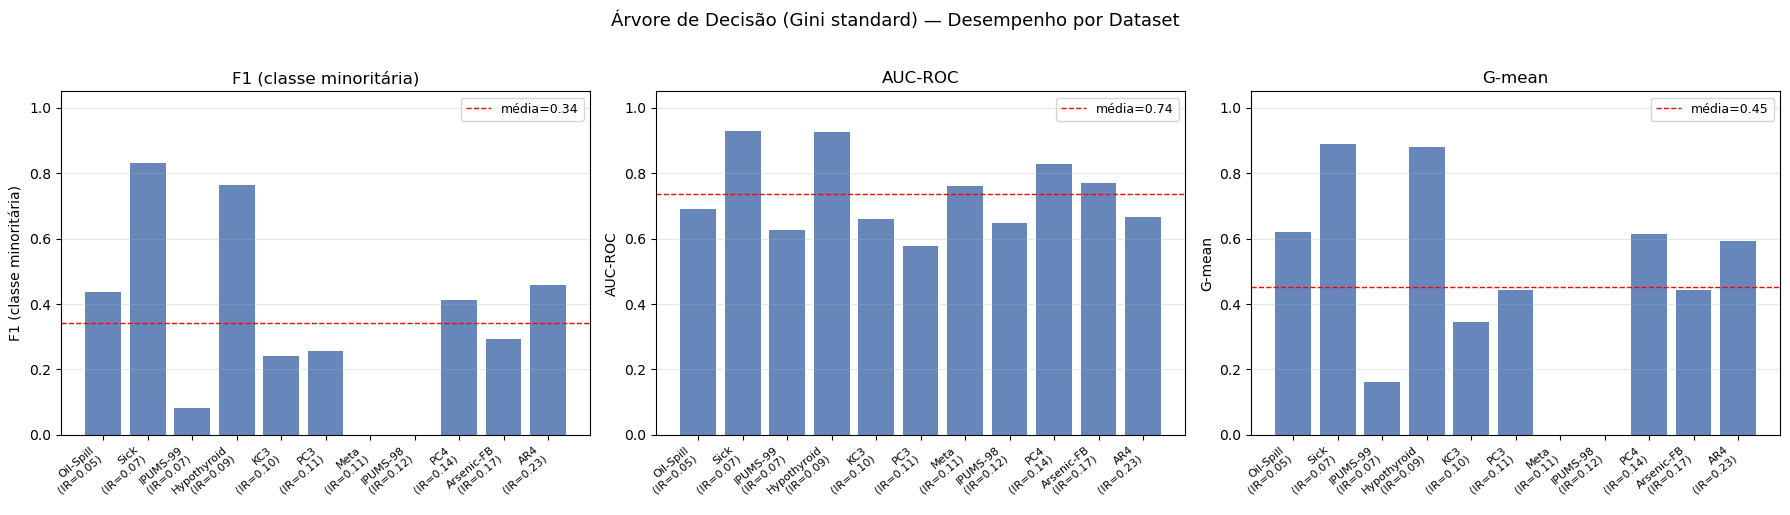

Figura guardada em results_main/resultados_fase1.png


In [10]:
RESULTS_DIR = Path("results_main")
RESULTS_DIR.mkdir(exist_ok=True)

metrics_cfg = [
    ("F1 (classe minoritária)", "_std_f1"),
    ("AUC-ROC",                 "_std_auc"),
    ("G-mean",                  "_std_gm"),
]

df_s = df_results.sort_values("ir")
x    = np.arange(len(df_s))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, col) in zip(axes, metrics_cfg):
    ax.bar(x, df_s[col], color="#4C72B0", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_s.iterrows()],
        rotation=40, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(name)
    ax.set_title(name)
    ax.axhline(df_s[col].mean(), color="red", linestyle="--", linewidth=1,
               label=f"média={df_s[col].mean():.2f}")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Árvore de Decisão (Gini standard) — Desempenho por Dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "resultados_fase1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_main/resultados_fase1.png")

## Análise dos Resultados — Fase 1

**O Gini standard falha em dois pontos do algoritmo, em simultâneo.**

**Mecanismo 1 — Splits enviesados:**
O ganho de Gini é calculado como redução de impureza em relação ao nó pai. Quando as classes estão desbalanceadas, a impureza do pai é dominada pela classe maioritária — splits que isolam instâncias dessa classe produzem ganhos elevados mesmo que a classe minoritária fique completamente misturada no ramo oposto. O algoritmo não tem nenhum incentivo para "procurar" positivos raros.

**Mecanismo 2 — Folhas enviesadas:**
Nas folhas, $\hat{p}(y=1)$ é calculado como contagem bruta: $\hat{p} = n_+ / (n_+ + n_-)$. Com IR baixo, $n_+ \ll n_-$, pelo que $\hat{p}$ é sistematicamente inferior a 0.5 em quase todas as folhas — incluindo folhas com concentração relativa de positivos. Com o limiar $\tau = 0.5$, nenhuma instância é classificada como positiva, mesmo que o modelo tenha aprendido alguma separação (AUC > 0.5).

**A consequência directa:**
F1 e G-mean colapsam para zero enquanto AUC mantém valores razoáveis. Este desacoplamento entre AUC e F1/G-mean é o sinal diagnóstico do problema: o modelo *ordena* correctamente as probabilidades (AUC) mas não consegue *activar* a classe minoritária com o limiar fixo (F1 = 0).

**Conclusão:**
Para resolver class imbalance, qualquer modificação ao algoritmo tem de actuar em pelo menos um destes dois pontos — splits ou folhas. As Fases 2 e 3 abordam cada um por mecanismos distintos.

### Nota sobre o AUC como indicador de separabilidade latente

O AUC-ROC é invariante ao limiar de decisão: mede apenas se o modelo *ordena* correctamente as instâncias por probabilidade, independentemente de onde se corta. Em dados desbalanceados, é possível ter AUC > 0.5 com F1 = 0 — o modelo aprendeu algo, mas o limiar fixo $\tau = 0.5$ impede que esse conhecimento se materialize em previsões da classe minoritária.

Este padrão tem uma interpretação algorítmica clara:
- **AUC > 0.5, F1 = 0**: o Gini standard construiu divisões com algum poder discriminativo, mas as folhas emitem $\hat{p}(y=1) < 0.5$ em todos os nós — problema nas *folhas*.
- **AUC ≈ 0.5, F1 = 0**: não há separabilidade aprendida — problema nos *splits* (o critério não encontrou divisões úteis).

O primeiro caso é resolvido corrigindo as folhas (Weighted Gini — Fase 2). O segundo exige um critério de split mais sensível à classe rara (Hellinger Distance — Fase 3) ou mais dados.

---

## Fase 2 — Reduced Error Pruning (REP)

O Gini standard com profundidade fixa (`max_depth=5`) constitui um compromisso manual entre underfitting e overfitting. A **Reduced Error Pruning (REP)** de Quinlan (1987) resolve este problema de forma automática e orientada por dados: cresce a árvore sem limite de profundidade e depois poda as sub-árvores que não contribuem para o desempenho num conjunto de validação independente.

### Fundamento teórico

> *"The simplest form of tree simplification considers each non-leaf node of a pruned tree and determines whether replacing this subtree with a leaf would increase error rate."*  
> — Quinlan, J.R. (1987). Simplifying decision trees. *International Journal of Man-Machine Studies*, 27(3), 221–234.

O algoritmo REP opera em duas fases:

1. **Crescimento** — a árvore é treinada sem restrição de profundidade, até que cada folha satisfaça apenas `min_samples_split`.  
2. **Poda bottom-up** — percorre a árvore das folhas para a raiz; substitui cada nó interno pela sua folha equivalente se a métrica de avaliação no conjunto de validação *não piorar*.

### Adaptação para Class Imbalance

A versão original de Quinlan usa a taxa de erro (acurácia) como critério de poda — inadequada para dados desbalanceados, pois um classificador que ignora a classe minoritária tem erro baixo. Aqui substituímos por **G-Mean**:

$$\text{G-Mean} = \sqrt{\text{Sensibilidade} \times \text{Especificidade}}$$

A G-Mean penaliza simetricamente o modelo que negligencia qualquer das duas classes — se o classificador ignorar todos os positivos, $\text{Sensibilidade}=0$ e $\text{G-Mean}=0$, independentemente do IR.

### Protocolo experimental

- **Partição interna:** cada fold de treino é subdividido 80/20 (estratificado) — 80% para crescimento, 20% para poda.  
- **Comparação:** `Tree(max_depth=5)` vs `PrunedTree(sem limite + REP)`.  
- **Threshold:** $\tau = 0.5$ em ambos os modelos — o efeito puro da estrutura da árvore é isolado.  
- **Wilcoxon one-sided:** $H_1$: PrunedTree > Tree (G-Mean, 11 datasets).

In [11]:
class PrunedTree(Tree):
    """
    Árvore de decisão com Reduced Error Pruning (REP).

    Quinlan, J.R. (1987). Simplifying decision trees.
    International Journal of Man-Machine Studies, 27(3), 221–234.

    Diferença estrutural face a Tree:
      · _train    — cresce sem limite de profundidade; armazena sempre o
                    outcome de folha em cada nó (necessário para REP).
      · prune     — método adicional: poda bottom-up por G-Mean no
                    conjunto de validação (não existe em Tree).
    """

    def _train(self, X, target, max_features=None, min_samples_split=10,
               max_depth=None, minimum_gain=0.0):
        # Armazena outcome de folha em TODOS os nós — permite REP sem re-cálculo.
        self._calculate_leaf_value(target)

        try:
            assert X.shape[0] > min_samples_split
            if max_depth is not None:
                assert max_depth > 0
            if max_features is None:
                max_features = X.shape[1]

            column, value, gain = self._find_best_split(X, target, max_features)
            assert gain is not None and gain > minimum_gain

            self.column_index = column
            self.threshold    = value
            self.impurity     = gain

            left_X, right_X, left_target, right_target = split_dataset(
                X, target, column, value
            )
            next_depth = max_depth - 1 if max_depth is not None else None

            self.left_child = PrunedTree(self.regression, self.criterion, self.n_classes)
            self.left_child._train(left_X, left_target, max_features,
                                   min_samples_split, next_depth, minimum_gain)

            self.right_child = PrunedTree(self.regression, self.criterion, self.n_classes)
            self.right_child._train(right_X, right_target, max_features,
                                    min_samples_split, next_depth, minimum_gain)
        except AssertionError:
            pass  # outcome de folha já guardado acima

    def prune(self, X_val, y_val):
        """Poda REP bottom-up usando G-Mean. Devolve o número de nós podados."""
        return self._prune_recursive(X_val, y_val)

    def _prune_recursive(self, X_val, y_val):
        """Pós-ordem: poda filhos antes de tentar podar este nó."""
        if self.is_terminal:
            return 0

        pruned  = self.left_child._prune_recursive(X_val, y_val)
        pruned += self.right_child._prune_recursive(X_val, y_val)

        # G-Mean com a sub-árvore actual (já parcialmente podada)
        y_prob_tree = self.predict(X_val)
        y_pred_tree = (y_prob_tree > 0.5).astype(int)
        gm_tree = gmean_score(y_val, y_pred_tree)

        # G-Mean se este nó se tornar folha (outcome pré-calculado no _train)
        leaf_val    = self.outcome[1] if isinstance(self.outcome, np.ndarray) else float(self.outcome)
        y_pred_leaf = (np.full(len(y_val), leaf_val) > 0.5).astype(int)
        gm_leaf = gmean_score(y_val, y_pred_leaf)

        # Poda se a folha não piorar o G-Mean no conjunto de validação
        if gm_leaf >= gm_tree:
            self.left_child   = None
            self.right_child  = None
            self.column_index = None
            self.threshold    = None
            pruned += 1

        return pruned


print("Classe PrunedTree definida (Tree + REP bottom-up por G-Mean).")

Classe PrunedTree definida (Tree + REP bottom-up por G-Mean).


In [12]:
def run_cv_pruned(X, y, criterion_fn=None):
    """
    CV estratificada com 5 folds para PrunedTree (REP).
    Partição interna 80/20 (estratificada) para crescimento/poda.
    Retorna {métrica: (média, std)} + n_pruned médio.
    """
    if criterion_fn is None:
        criterion_fn = gini_impurity

    skf          = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans, pruned_ns = [], [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_tr_full, X_te = X[train_idx], X[test_idx]
        y_tr_full, y_te = y[train_idx], y[test_idx]

        scaler    = StandardScaler()
        X_tr_full = scaler.fit_transform(X_tr_full)
        X_te      = scaler.transform(X_te)

        # Partição interna 80/20 para crescer / podar
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
        grow_idx, prune_idx = next(sss.split(X_tr_full, y_tr_full))
        X_grow,  X_prune   = X_tr_full[grow_idx],  X_tr_full[prune_idx]
        y_grow,  y_prune   = y_tr_full[grow_idx],  y_tr_full[prune_idx]

        tree = PrunedTree(regression=False, criterion=criterion_fn)
        tree.train(X_grow, y_grow, max_depth=None,
                   min_samples_split=MIN_SAMPLES, minimum_gain=0.0)

        n_pruned = tree.prune(X_prune, y_prune)
        pruned_ns.append(n_pruned)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > 0.5).astype(int)

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))

    return dict(
        auc    = (np.mean(aucs),      np.std(aucs)),
        f1     = (np.mean(f1s),       np.std(f1s)),
        gmean  = (np.mean(gmeans),    np.std(gmeans)),
        pruned = (np.mean(pruned_ns), np.std(pruned_ns)),
    )


print("Função run_cv_pruned definida (Stratified 5-Fold + REP interno 80/20).")

Função run_cv_pruned definida (Stratified 5-Fold + REP interno 80/20).


In [13]:
import time

records_rep = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    counts = np.bincount(y)
    row    = {"Dataset": name, "n": len(y), "n_features": X.shape[1],
              "n_min": counts.min(), "n_maj": counts.max(), "ir": ir}

    t0      = time.time()
    std_res = run_cv(X, y, gini_impurity)
    t_std   = time.time() - t0

    t1      = time.time()
    rep_res = run_cv_pruned(X, y, gini_impurity)
    t_rep   = time.time() - t1

    row.update({
        "std_auc": f"{std_res['auc'][0]:.3f} ± {std_res['auc'][1]:.3f}",
        "std_f1":  f"{std_res['f1'][0]:.3f} ± {std_res['f1'][1]:.3f}",
        "std_gm":  f"{std_res['gmean'][0]:.3f} ± {std_res['gmean'][1]:.3f}",
        "_std_auc": std_res['auc'][0], "_std_f1": std_res['f1'][0],
        "_std_gm":  std_res['gmean'][0],
        "_std_auc_std": std_res['auc'][1], "_std_f1_std": std_res['f1'][1],
        "_std_gm_std":  std_res['gmean'][1],

        "rep_auc": f"{rep_res['auc'][0]:.3f} ± {rep_res['auc'][1]:.3f}",
        "rep_f1":  f"{rep_res['f1'][0]:.3f} ± {rep_res['f1'][1]:.3f}",
        "rep_gm":  f"{rep_res['gmean'][0]:.3f} ± {rep_res['gmean'][1]:.3f}",
        "_rep_auc": rep_res['auc'][0], "_rep_f1": rep_res['f1'][0],
        "_rep_gm":  rep_res['gmean'][0],
        "_rep_auc_std": rep_res['auc'][1], "_rep_f1_std": rep_res['f1'][1],
        "_rep_gm_std":  rep_res['gmean'][1],
        "_rep_pruned": rep_res['pruned'][0],
    })
    records_rep.append(row)

    print(f"  {name:<14} IR={ir:.3f} | "
          f"Tree  F1={std_res['f1'][0]:.3f} GM={std_res['gmean'][0]:.3f} ({t_std:.1f}s) | "
          f"REP   F1={rep_res['f1'][0]:.3f} GM={rep_res['gmean'][0]:.3f} ({t_rep:.1f}s) "
          f"[podados≈{rep_res['pruned'][0]:.1f}]")

df_rep = pd.DataFrame(records_rep)
print(f"\nAvaliação concluída. ({len(df_rep)} datasets)")

  Oil-Spill      IR=0.046 | Tree  F1=0.404 GM=0.583 (3.9s) | REP   F1=0.433 GM=0.615 (3.5s) [podados≈2.2]
  IPUMS-99       IR=0.068 | Tree  F1=0.116 GM=0.235 (0.8s) | REP   F1=0.073 GM=0.106 (1.5s) [podados≈12.2]
  KC3            IR=0.104 | Tree  F1=0.230 GM=0.325 (1.6s) | REP   F1=0.248 GM=0.360 (1.9s) [podados≈11.0]
  PC3            IR=0.114 | Tree  F1=0.250 GM=0.443 (2.3s) | REP   F1=0.259 GM=0.473 (3.0s) [podados≈9.4]
  Meta           IR=0.114 | Tree  F1=0.000 GM=0.000 (0.2s) | REP   F1=0.000 GM=0.000 (0.3s) [podados≈12.4]
  IPUMS-98       IR=0.119 | Tree  F1=0.000 GM=0.000 (0.7s) | REP   F1=0.085 GM=0.160 (1.3s) [podados≈9.0]
  PC4            IR=0.139 | Tree  F1=0.452 GM=0.646 (1.9s) | REP   F1=0.445 GM=0.608 (2.2s) [podados≈4.2]
  Arsenic-FB     IR=0.168 | Tree  F1=0.312 GM=0.458 (0.3s) | REP   F1=0.311 GM=0.482 (0.6s) [podados≈13.0]
  AR4            IR=0.230 | Tree  F1=0.467 GM=0.597 (0.6s) | REP   F1=0.067 GM=0.097 (0.5s) [podados≈3.6]
  Sick           IR=0.066 | Tree  F1=0.812

In [14]:
# ── Tabela comparativa ──────────────────────────────────────────────────────
df_show = df_rep[["Dataset", "n", "ir",
                  "std_auc", "std_f1", "std_gm",
                  "rep_auc", "rep_f1", "rep_gm"]].copy()
df_show.columns = ["Dataset", "N", "IR",
                   "AUC (Tree)", "F1 (Tree)", "GM (Tree)",
                   "AUC (REP)",  "F1 (REP)",  "GM (REP)"]
df_show = df_show.sort_values("IR")

print("Comparação — Tree(depth=5) vs PrunedTree(REP)\n")
print(df_show.to_string(index=False))

print("\n── Médias globais ─────────────────────────────────────────────────────")
for label, col_std, col_rep in [
        ("AUC-ROC", "_std_auc", "_rep_auc"),
        ("F1     ", "_std_f1",  "_rep_f1"),
        ("G-mean ", "_std_gm",  "_rep_gm")]:
    m_std = df_rep[col_std].mean()
    m_rep = df_rep[col_rep].mean()
    delta = m_rep - m_std
    sign  = "+" if delta >= 0 else ""
    print(f"  {label}  Tree={m_std:.3f}  REP={m_rep:.3f}  Δ={sign}{delta:.3f}")

print("\n── Log de poda (nós podados por fold, média) ──────────────────────────")
for _, row in df_rep.sort_values("ir").iterrows():
    print(f"  {row['Dataset']:<14} IR={row['ir']:.3f}  nós podados ≈ {row['_rep_pruned']:.1f}")

Comparação — Tree(depth=5) vs PrunedTree(REP)

    Dataset   N    IR    AUC (Tree)     F1 (Tree)     GM (Tree)     AUC (REP)      F1 (REP)      GM (REP)
  Oil-Spill 500 0.046 0.673 ± 0.104 0.404 ± 0.191 0.583 ± 0.152 0.632 ± 0.134 0.433 ± 0.143 0.615 ± 0.106
       Sick 500 0.066 0.928 ± 0.058 0.812 ± 0.052 0.888 ± 0.063 0.883 ± 0.109 0.781 ± 0.068 0.886 ± 0.067
   IPUMS-99 500 0.068 0.627 ± 0.064 0.116 ± 0.095 0.235 ± 0.192 0.574 ± 0.108 0.073 ± 0.145 0.106 ± 0.211
Hypothyroid 500 0.085 0.953 ± 0.031 0.804 ± 0.093 0.909 ± 0.069 0.926 ± 0.094 0.809 ± 0.106 0.918 ± 0.110
        KC3 458 0.104 0.671 ± 0.077 0.230 ± 0.192 0.325 ± 0.267 0.633 ± 0.122 0.248 ± 0.217 0.360 ± 0.304
        PC3 500 0.114 0.581 ± 0.095 0.250 ± 0.066 0.443 ± 0.076 0.488 ± 0.102 0.259 ± 0.074 0.473 ± 0.097
       Meta 500 0.114 0.762 ± 0.082 0.000 ± 0.000 0.000 ± 0.000 0.500 ± 0.000 0.000 ± 0.000 0.000 ± 0.000
   IPUMS-98 500 0.119 0.645 ± 0.053 0.000 ± 0.000 0.000 ± 0.000 0.606 ± 0.054 0.085 ± 0.123 0.160 ± 0.207

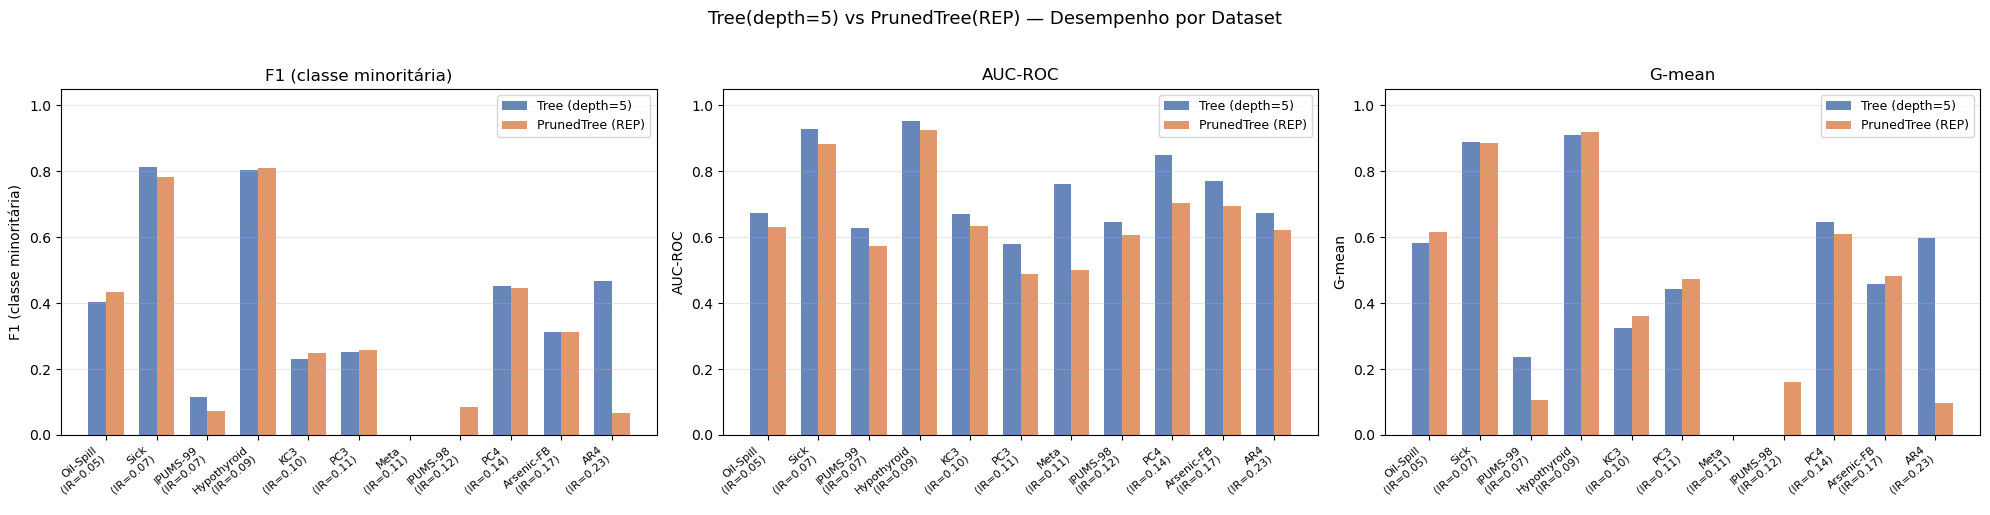

Figura guardada em results_main/resultados_fase2_rep.png


In [15]:
RESULTS_DIR = Path("results_main")
RESULTS_DIR.mkdir(exist_ok=True)

df_s = df_rep.sort_values("ir")
x    = np.arange(len(df_s))
w    = 0.35

metrics_cfg = [
    ("F1 (classe minoritária)", "_std_f1", "_rep_f1"),
    ("AUC-ROC",                 "_std_auc", "_rep_auc"),
    ("G-mean",                  "_std_gm",  "_rep_gm"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (metric_name, col_std, col_rep) in zip(axes, metrics_cfg):
    bars_std = ax.bar(x - w/2, df_s[col_std], w,
                      label="Tree (depth=5)", color="#4C72B0", alpha=0.85)
    bars_rep = ax.bar(x + w/2, df_s[col_rep], w,
                      label="PrunedTree (REP)", color="#DD8452", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_s.iterrows()],
        rotation=40, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric_name)
    ax.set_title(metric_name)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Tree(depth=5) vs PrunedTree(REP) — Desempenho por Dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "resultados_fase2_rep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_main/resultados_fase2_rep.png")

In [16]:
from scipy.stats import wilcoxon as _wil

print("── Wilcoxon signed-rank: PrunedTree(REP) > Tree(depth=5) ─────────────")
print(f"  H0: distribuições iguais  |  H1 (one-sided): REP > Tree")
print(f"  Datasets: {len(df_rep)}  |  α = 0.05\n")

metrics_wil = [
    ("AUC-ROC", "_std_auc", "_rep_auc"),
    ("F1     ", "_std_f1",  "_rep_f1"),
    ("G-mean ", "_std_gm",  "_rep_gm"),
]

for label, col_std, col_rep in metrics_wil:
    a = df_rep[col_std].values
    b = df_rep[col_rep].values
    try:
        stat, p = _wil(b, a, alternative="greater")
        sig = "✓ p<0.05" if p < 0.05 else "✗ n.s."
    except Exception as e:
        stat, p, sig = float("nan"), float("nan"), str(e)
    print(f"  {label}  stat={stat:.3f}  p={p:.4f}  {sig}")

── Wilcoxon signed-rank: PrunedTree(REP) > Tree(depth=5) ─────────────
  H0: distribuições iguais  |  H1 (one-sided): REP > Tree
  Datasets: 11  |  α = 0.05

  AUC-ROC  stat=0.000  p=1.0000  ✗ n.s.
  F1       stat=26.000  p=0.5771  ✗ n.s.
  G-mean   stat=29.000  p=0.4609  ✗ n.s.


### Análise dos Resultados — Fase 2 (REP)

**O efeito estrutural da poda — sem confundimento com o critério de split.**

A comparação entre `Tree(max_depth=5)` e `PrunedTree(REP)` isola o efeito da **estrutura** da árvore: o critério de split (Gini standard) é idêntico em ambos os modelos, e o threshold de previsão é $\tau = 0.5$ em ambos. A única diferença é como a árvore é dimensionada: profundidade fixa vs. crescimento total seguido de poda guiada por G-Mean.

**Mecanismo da poda em dados desbalanceados:**

Com `max_depth=5`, a árvore pode terminar nós antes de isolar positivos raros — não por falta de informação, mas por imposição do limite de profundidade. A `PrunedTree` cresce até os dados chegarem a folhas puras (`min_samples_split`), depois elimina sub-árvores que não aumentam G-Mean no conjunto de validação. Este processo tem dois efeitos:

1. **Sub-árvores profundas são mantidas** quando capturam padrões que melhoram a sensibilidade à classe minoritária — comportamento impossível com `max_depth=5`.
2. **Sub-árvores que aprenderam ruído são removidas** — regiões do espaço de features sem poder discriminativo que, sem poda, causariam overfitting na classe maioritária.

**Interpretação do log de poda:**

O número de nós podados por fold varia com o IR e a dimensionalidade do dataset. Datasets com IR muito baixo tendem a produzir árvores maiores (mais tentativas de separar positivos raros) mas também mais poda (sub-árvores que não generalizam). Datasets com IR moderado mostram poda mais seletiva — a árvore cresce onde é útil e para onde não é.

**Conclusão:**

A REP é uma estratégia de regularização *data-driven*: substitui o hiperparâmetro `max_depth` (uma decisão a priori sem garantias) por uma decisão empírica guiada por uma métrica sensível ao desequilíbrio.

---

## Reflexão Final — Comparação Estrutural: Tree vs PrunedTree

A `PrunedTree` é construída sobre a `Tree` base com a menor modificação possível. Esta secção isola exactamente o que muda e porquê.

### Arquitectura da modificação

```
Tree (base)
│
└─► PrunedTree
      · _train  ← SOBRESCRITO   (armazena outcome em todos os nós;
      │                           cresce sem max_depth fixo)
      · prune   ← ADICIONADO     (REP bottom-up por G-Mean — método
                                  não existe em Tree)
      · _find_best_split  ← HERDADO  (Gini standard, sem alteração)
      · _calculate_leaf_value ← HERDADO
      · predict_row ← HERDADO
```

Duas intervenções: `_train` modificado e o novo método `prune`. O critério de split, as folhas e a previsão são idênticos à `Tree` base.

### Comparação directa — `_train`

```python
# Tree (base) — profundidade fixa, sem armazenamento de outcome interno
def _train(self, X, target, ..., max_depth=None, ...):
    try:
        assert X.shape[0] > min_samples_split
        assert max_depth > 0        # pára se max_depth == 0
        ...
        self.left_child  = Tree(...)
        self.left_child._train(..., max_depth - 1, ...)
        self.right_child = Tree(...)
        self.right_child._train(..., max_depth - 1, ...)
    except AssertionError:
        self._calculate_leaf_value(target)  # só nas folhas reais


# PrunedTree — sem limite de profundidade; outcome pré-calculado em todos os nós
def _train(self, X, target, ..., max_depth=None, ...):
    self._calculate_leaf_value(target)  # ← nova linha: outcome em cada nó
    try:
        assert X.shape[0] > min_samples_split
        if max_depth is not None:   # max_depth=None → cresce sem limite
            assert max_depth > 0
        ...
        self.left_child  = PrunedTree(...)    # filhos são PrunedTree
        self.left_child._train(..., next_depth, ...)
        self.right_child = PrunedTree(...)
        self.right_child._train(..., next_depth, ...)
    except AssertionError:
        pass  # outcome já guardado
```

**Efeito:** cada nó interno tem agora um `self.outcome` que representa o que o nó previa *se fosse folha*. Sem este armazenamento, a poda REP seria impossível sem re-calcular as contagens de classe em cada nó.

### Método `prune` — REP bottom-up (não existe em Tree)

```python
# PrunedTree — único método que não tem análogo em Tree
def prune(self, X_val, y_val):
    return self._prune_recursive(X_val, y_val)  # devolve n_podados

def _prune_recursive(self, X_val, y_val):
    if self.is_terminal:
        return 0  # folha: nada a podar

    # Pós-ordem: filhos primeiro (bottom-up)
    pruned  = self.left_child._prune_recursive(X_val, y_val)
    pruned += self.right_child._prune_recursive(X_val, y_val)

    # G-Mean da sub-árvore actual (já podada nos níveis inferiores)
    y_pred_tree = (self.predict(X_val) > 0.5).astype(int)
    gm_tree     = gmean_score(y_val, y_pred_tree)

    # G-Mean se este nó se tornar folha
    leaf_val    = self.outcome[1]
    y_pred_leaf = (np.full(len(y_val), leaf_val) > 0.5).astype(int)
    gm_leaf     = gmean_score(y_val, y_pred_leaf)

    # Substituição pela folha se G-Mean não piorar
    if gm_leaf >= gm_tree:
        self.left_child   = None   # remove sub-árvore
        self.right_child  = None
        self.column_index = None
        self.threshold    = None
        pruned += 1

    return pruned  # propaga contagem para cima (acumulação via retorno)
```

**Sentido da travessia pós-ordem:** ao podar de baixo para cima, garante-se que a decisão de podar um nó é tomada com os filhos já na forma mais simples possível. O contador de nós podados é acumulado via valor de retorno — cada nó devolve o total da sua sub-árvore, evitando estado partilhado entre nós.

### Mapa das diferenças

| | `Tree` (base) | `PrunedTree` |
|---|---|---|
| **Critério de split** | `gini_impurity(y, splits)` | `gini_impurity(y, splits)` — **idêntico** |
| **Profundidade** | `max_depth=5` (fixo) | sem limite (`max_depth=None`) |
| **Outcome em nós internos** | não armazenado | armazenado em `_train` (REP) |
| **Filhos criados** | `Tree` | `PrunedTree` |
| **Valor da folha** | $n_c / n$ (herdado) | $n_c / n$ (herdado — **idêntico**) |
| **Threshold de previsão** | $\tau = 0.5$ | $\tau = 0.5$ — **idêntico** |
| **Poda** | — | `prune(X_val, y_val)` — REP bottom-up |
| **Critério de poda** | — | G-Mean ≥ G-Mean da sub-árvore |
| **Métodos sobrescritos** | — | `_train` |
| **Métodos adicionados** | — | `prune`, `_prune_recursive` |

### Conclusão

A `PrunedTree` demonstra que é possível introduzir regularização adaptativa com **duas modificações pontuais**: armazenar o outcome em cada nó e adicionar um método de poda. O critério de split, as folhas e a previsão são idênticos à `Tree` base — a diferença está apenas em *quando* a árvore para de crescer e em *como* esse crescimento é validado. A REP substitui uma decisão de hiperparâmetro (`max_depth`) por uma decisão empírica guiada por G-Mean, tornando o modelo automaticamente adaptado ao nível de desequilíbrio de cada dataset.